# ДЗ 4

Определение промотеров в ДНК (Бинарная классификация) на датасете `human_nontata_promoters`

## Настройка окружения

In [1]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category=warn)

from genomic_benchmarks.data_check import info
from genomic_benchmarks.loc2seq import download_dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

from genomic_benchmarks.dataset_getters.pytorch_datasets import HumanNontataPromoters
import torch
from torch import nn
import matplotlib.pyplot as plt
import os, random, time
import numpy as np

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## Подготовка Датасета

In [3]:
DS_NAME = "human_nontata_promoters"
info(DS_NAME, version=0)

Dataset `human_nontata_promoters` has 2 classes: negative, positive.

All lengths of genomic intervals equals 251.

Totally 36131 sequences have been found, 27097 for training and 9034 for testing.


,train,test
negative,12355,4119
positive,14742,4915


In [4]:
root = download_dataset(DS_NAME, version=0)
train_raw = HumanNontataPromoters("train")
test_raw = HumanNontataPromoters("test")

In [5]:
class KmerTokenizer:
    def __init__(self, k=6):
        self.k = k
        bases = ['A', 'C', 'G', 'T']
        from itertools import product
        kmers = [''.join(p) for p in product(bases, repeat=k)]
        self.kmer2idx = {km: i+1 for i, km in enumerate(kmers)}  # 0 = unknown/N
        self.vocab_size = len(self.kmer2idx) + 1

    def encode(self, seq):
        return [self.kmer2idx.get(seq[i:i+self.k], 0) for i in range(len(seq) - self.k + 1)]

In [6]:
class DNATokenizedDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.dna_map = {"A": 1, "T": 2, "G": 3, "C": 4, "N": 5}
        self.vocab_size = len(self.dna_map) + 1 

    def __len__(self):
        return len(self.base_dataset)

    def encode(self, nucleotide):
        return self.dna_map.get(nucleotide, self.dna_map["N"])

    def __getitem__(self, idx):
        seq, label = self.base_dataset[idx]
        x = torch.tensor([self.encode(ch) for ch in seq.upper()], dtype=torch.long)
        y = torch.tensor(label, dtype=torch.long)
        return x, y

class DNAKmerDataset(Dataset):
    def __init__(self, base_dataset, k=6):
        self.base_dataset = base_dataset
        self.k = k
        from itertools import product
        bases = ['A', 'C', 'G', 'T']
        kmers = [''.join(p) for p in product(bases, repeat=k)]
        self.kmer2idx = {km: i + 1 for i, km in enumerate(kmers)}  # 0 = unknown/N-containing

    @property
    def vocab_size(self):
        return len(self.kmer2idx) + 1  # 4^k + 1

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        seq, label = self.base_dataset[idx]
        seq = seq.upper()
        tokens = [self.kmer2idx.get(seq[i:i+self.k], 0) for i in range(len(seq) - self.k + 1)]
        x = torch.tensor(tokens, dtype=torch.long)
        y = torch.tensor(label, dtype=torch.long)
        return x, y

In [7]:
def split_train_val(full_train_dataset, val_ratio=0.2):
    val_size = int(len(full_train_dataset) * val_ratio)
    train_size = len(full_train_dataset) - val_size
    generator = torch.Generator().manual_seed(SEED)
    return random_split(full_train_dataset, [train_size, val_size], generator=generator)

# full_train_dataset = DNATokenizedDataset(train_raw)
# test_dataset = DNATokenizedDataset(test_raw)
# train_dataset, val_dataset = split_train_val(full_train_dataset)

k = 4
full_train_dataset = DNAKmerDataset(train_raw, k=k)
test_dataset = DNAKmerDataset(test_raw, k=k)
train_dataset, val_dataset = split_train_val(full_train_dataset)


## Архитектура Модели

Модель будет состоять только из mLSTM блоков и MLP классификатора.

Я модифицировал forward pass, чтобы больше парралеллизовать проходы (считаем все гейты, а уже потом только hidden state)

In [ ]:
class CausalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation, **kwargs)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]


class BlockDiagonal(nn.Module):
    def __init__(self, in_features, out_features, num_blocks):
        super().__init__()
        assert out_features % num_blocks == 0
        block_out_features = out_features // num_blocks
        self.blocks = nn.ModuleList([
            nn.Linear(in_features, block_out_features)
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        return torch.cat([block(x) for block in self.blocks], dim=-1)


class mLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=2):
        super().__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads

        self.layer_norm = nn.LayerNorm(input_size)
        self.up_proj_left = nn.Linear(input_size, int(input_size * proj_factor))
        self.up_proj_right = nn.Linear(input_size, self.hidden_size)
        self.down_proj = nn.Linear(self.hidden_size, input_size)

        self.causal_conv = CausalConv1D(1, 1, 4)
        self.skip_connection = nn.Linear(int(input_size * proj_factor), self.hidden_size)

        self.Wq = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wk = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wv = BlockDiagonal(int(input_size * proj_factor), self.hidden_size, num_heads)
        self.Wi = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wf = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wo = nn.Linear(int(input_size * proj_factor), self.hidden_size)

        self.group_norm = nn.GroupNorm(num_heads, self.hidden_size)

    def forward_sequence(self, x_seq):
        batch_size, seq_len, _ = x_seq.shape
        BT = batch_size * seq_len

        x_norm = self.layer_norm(x_seq)
        x_up_left = self.up_proj_left(x_norm)
        x_up_right = self.up_proj_right(x_norm)

        x_conv = x_up_left.reshape(BT, 1, -1)
        x_conv = F.silu(self.causal_conv(x_conv).reshape(batch_size, seq_len, -1))
        x_skip = self.skip_connection(x_conv)

        q = self.Wq(x_conv)
        k = self.Wk(x_conv) / (self.head_size ** 0.5)
        v = self.Wv(x_up_left)

        i_tilde = self.Wi(x_conv)
        f_tilde = self.Wf(x_conv)
        o = torch.sigmoid(self.Wo(x_up_left))

        c = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)
        n = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)
        m = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)

        h_seq = []
        for t in range(seq_len):
            q_t, k_t, v_t = q[:, t], k[:, t], v[:, t]
            i_t, f_t, o_t = i_tilde[:, t], f_tilde[:, t], o[:, t]

            m_t = torch.max(f_t + m, i_t)
            i_gate = torch.exp(i_t - m_t)
            f_gate = torch.exp(f_t + m - m_t)

            c = f_gate * c + i_gate * (v_t * k_t)
            n = f_gate * n + i_gate * k_t
            m = m_t

            h_t = o_t * (c * q_t) / torch.max(
                torch.abs(n * q_t).sum(dim=-1, keepdim=True),
                torch.ones(1, device=x_seq.device)
            )
            h_seq.append(h_t)

        h_seq = torch.stack(h_seq, dim=1)

        h_flat = h_seq.reshape(BT, self.hidden_size)
        output = self.group_norm(h_flat).reshape(batch_size, seq_len, self.hidden_size)
        output = output + x_skip
        output = output * F.silu(x_up_right)
        output = self.down_proj(output) + x_seq

        internals = {'q': q, 'k': k, 'i_tilde': i_tilde, 'f_tilde': f_tilde}
        return output, internals


class xLSTMClassifier(nn.Module):
    def __init__(self, vocab_size=6, embed_dim=64, head_size=16,
                 num_heads=4, num_layers=1, num_classes=2, proj_factor=2, max_seq_len=251):
        super().__init__()
        self.embed_dim = embed_dim
        self.hidden_size = head_size * num_heads
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        self.blocks = nn.ModuleList([
            mLSTMBlock(embed_dim, head_size, num_heads, proj_factor)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.30),
            nn.Linear(embed_dim, num_classes),
        )
        self.internals = {}

    def forward(self, x):
        _, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.embedding(x)
        x += self.pos_embed(positions)
        all_internals = {}
        for idx, block in enumerate(self.blocks):
            x, internals = block.forward_sequence(x)
            all_internals[idx] = internals
        self.internals = all_internals
        logits = self.classifier(x[:, -1])
        return logits

## Обучение 

In [ ]:
BATCH_SIZE = 128
NUM_EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-2

EMBED_DIM = 64
HEAD_SIZE = 16
NUM_HEADS = 6
NUM_LAYERS = 2
NUM_CLASSES = 2


device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = xLSTMClassifier(
    vocab_size=full_train_dataset.vocab_size, embed_dim=EMBED_DIM, head_size=HEAD_SIZE,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, max_seq_len=SEQ_LEN,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=3)
counts = torch.tensor([12355, 14742], dtype=torch.float)
weights = (1.0 / counts) / (1.0 / counts).sum()
criterion = nn.CrossEntropyLoss(weight=weights.to(device), label_smoothing=0.1)

Total parameters: 363,596


In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    start_pos = 0 #

    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
    
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        total_loss += loss.item() * batch_x.size(0)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="binary")
    return avg_loss, acc, f1, all_preds, all_labels

In [12]:
best_val_f1 = float("-inf")
best_model_state = None
patience, patience_counter = 10, 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f} | "
          f"{elapsed:.1f}s")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
assert best_model_state is not None, "No model state was saved during training!"
model.load_state_dict(best_model_state)

Epoch  1/30 | Train Loss: 0.5290  Acc: 0.7592 | Val Loss: 0.4786  Acc: 0.8134  F1: 0.8064 | 115.7s
Epoch  2/30 | Train Loss: 0.4536  Acc: 0.8284 | Val Loss: 0.4317  Acc: 0.8450  F1: 0.8409 | 115.6s
Epoch  3/30 | Train Loss: 0.4012  Acc: 0.8689 | Val Loss: 0.4174  Acc: 0.8594  F1: 0.8539 | 116.1s
Epoch  4/30 | Train Loss: 0.4023  Acc: 0.8693 | Val Loss: 0.4017  Acc: 0.8669  F1: 0.8603 | 117.1s
Epoch  5/30 | Train Loss: 0.3693  Acc: 0.8914 | Val Loss: 0.4190  Acc: 0.8513  F1: 0.8232 | 117.3s
Epoch  6/30 | Train Loss: 0.3286  Acc: 0.9203 | Val Loss: 0.4051  Acc: 0.8701  F1: 0.8567 | 116.8s
Epoch  7/30 | Train Loss: 0.3481  Acc: 0.9033 | Val Loss: 0.4130  Acc: 0.8603  F1: 0.8388 | 115.7s
Epoch  8/30 | Train Loss: 0.3179  Acc: 0.9260 | Val Loss: 0.4182  Acc: 0.8664  F1: 0.8551 | 116.4s
Epoch  9/30 | Train Loss: 0.2682  Acc: 0.9607 | Val Loss: 0.4439  Acc: 0.8609  F1: 0.8471 | 117.0s
Epoch 10/30 | Train Loss: 0.2884  Acc: 0.9458 | Val Loss: 0.4384  Acc: 0.8583  F1: 0.8435 | 115.3s
Epoch 11/3

<All keys matched successfully>

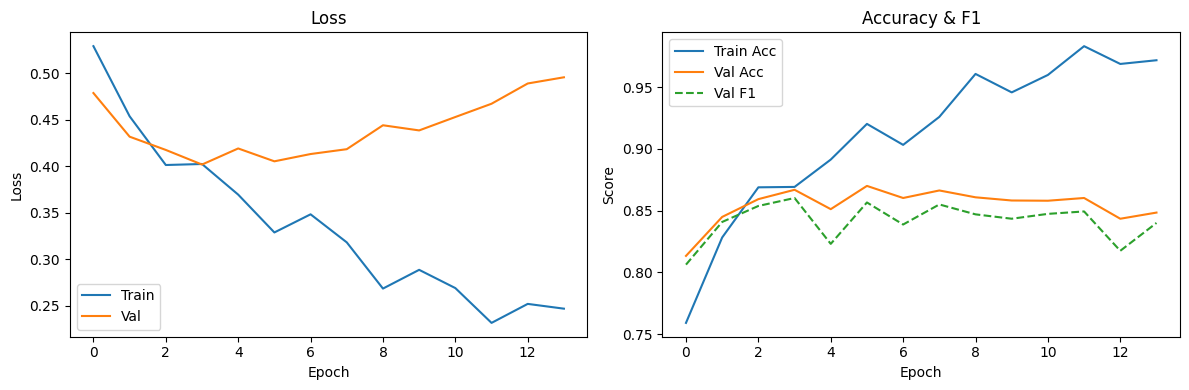

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.set_title("Loss")

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.plot(history["val_f1"], label="Val F1", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.legend()
ax2.set_title("Accuracy & F1")

plt.tight_layout()
plt.show()

In [14]:
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}  F1: {test_f1:.4f}")
print(classification_report(test_labels, test_preds, target_names=["positive", "negative"]))

Test Loss: 0.4018  Acc: 0.8704  F1: 0.8653
              precision    recall  f1-score   support

    positive       0.92      0.83      0.88      4915
    negative       0.82      0.91      0.87      4119

    accuracy                           0.87      9034
   macro avg       0.87      0.87      0.87      9034
weighted avg       0.88      0.87      0.87      9034



## Анализ Attention
### Attention + Forget
Вес attention рассчитвыается вот так:
$$
a(t, j) = |q_t \cdot k_j| \times i_j \times \prod_{s=j+1}^{t} f_s
$$
Где:
- $|q_t \cdot k_j|$ - на сколько сильно связан ключ с запросом в данный момент $t$
- $i_j$ - значение input gate (понятно, почему берем)
- $\prod_{s=j+1}^{t} f_s$ - кумулятивный forget gate (на сколько сильно мы забыти этот участок до момента $t$)

Так как данные - последовательности длины 250, логично взять $t=250$, ведь именно это момент потом идет в голову классификатора.

Далее выберем случайных представителей каждого класса (которые корректно классифицируются моделью) и посчитаем для них attention

### QK x Input  
Это та-же самая метрика, что и предыдущая, но без forget gate (ибо он убывает экспоненциально)
$$
a(j) = |q_t \cdot k_j| \times i_j 
$$

### Gradient Saliency:
Это L2 норма градиента логита относително вектора эмбеда на позиции $j$
$$
s(j) = \left\| \frac{\partial \text{logit}_c}{\partial e_j}\right\|_2
$$
Она считает на сколько каждая позиция вектора повлияла на принятое решение (значение логита) для всех слоев

### Считаем метрики

In [15]:
model.eval()
prom_data = []
nonprom_data = []
TARGET_SAMPLES = 200

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        if len(prom_data) >= TARGET_SAMPLES and len(nonprom_data) >= TARGET_SAMPLES:
            break
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        logits = model(batch_x)
        preds = logits.argmax(dim=-1)
        internals = model.internals[0]
        correct = (preds == batch_y)

        for i in range(batch_x.size(0)):
            if not correct[i]:
                continue
            entry = (
                internals['q'][i].cpu(), internals['k'][i].cpu(),
                internals['i_tilde'][i].cpu(), internals['f_tilde'][i].cpu(),
                batch_x[i].cpu(),
            )
            if batch_y[i].item() == 0 and len(prom_data) < TARGET_SAMPLES:
                prom_data.append(entry)
            elif batch_y[i].item() == 1 and len(nonprom_data) < TARGET_SAMPLES:
                nonprom_data.append(entry)

print(f"Collected {len(prom_data)} promoters, {len(nonprom_data)} non-promoters")

Collected 200 promoters, 200 non-promoters


In [16]:
def compute_attention_no_forget(q, k, i_tilde, f_tilde):
    T, H = q.shape
    m = torch.zeros(H)
    i_gates = []
    for t in range(T):
        m_t = torch.max(f_tilde[t] + m, i_tilde[t])
        i_gates.append(torch.exp(i_tilde[t] - m_t))
        m = m_t
    i_gates = torch.stack(i_gates)

    qk = (q[-1].unsqueeze(0) * k).sum(dim=-1).abs()
    inp = i_gates.mean(dim=-1)
    profile = qk * inp
    return profile / profile.sum()


def compute_gradient_saliency(model, x, target_class, device):
    model.eval()
    x_in = x.unsqueeze(0).to(device)

    embed_out = []
    def hook_fn(module, inp, out):
        out.retain_grad()
        embed_out.append(out)

    handle = model.embedding.register_forward_hook(hook_fn)
    logits = model(x_in)
    model.zero_grad()
    logits[0, target_class].backward()
    handle.remove()

    grad = embed_out[0].grad[0]
    saliency = grad.norm(dim=-1).detach().cpu()
    return saliency / saliency.sum()

def compute_attention_with_forget(q, k, i_tilde, f_tilde):
    T, H = q.shape
    m = torch.zeros(H)
    i_gates, f_gates = [], []
    for t in range(T):
        m_t = torch.max(f_tilde[t] + m, i_tilde[t])
        i_gates.append(torch.exp(i_tilde[t] - m_t))
        f_gates.append(torch.exp(f_tilde[t] + m - m_t))
        m = m_t
    i_gates = torch.stack(i_gates)
    f_gates = torch.stack(f_gates)

    qk = (q[-1].unsqueeze(0) * k).sum(dim=-1).abs()
    inp = i_gates.mean(dim=-1)

    cum_forget = torch.ones(T)
    for j in range(T - 2, -1, -1):
        cum_forget[j] = cum_forget[j + 1] * f_gates[j + 1].mean()

    profile = qk * inp * cum_forget
    return profile / profile.sum()

def profile_from_entry(entry):
    q, k, i_t, f_t, tokens = entry
    return compute_attention_no_forget(q, k, i_t, f_t)[-1]


idx_to_nuc = {1: 'A', 2: 'T', 3: 'G', 4: 'C', 5: 'N', 0: '-'}
def decode_seq(token_ids):
    return ''.join(idx_to_nuc[t.item()] for t in token_ids)

In [17]:
num_samples = min(len(prom_data), len(nonprom_data))

# Original attention (with forget gate)
orig_prom = torch.stack([compute_attention_with_forget(*e[:4]) for e in prom_data[:num_samples]])
orig_nonprom = torch.stack([compute_attention_with_forget(*e[:4]) for e in nonprom_data[:num_samples]])
# QK × input gate (no forget)
nf_prom = torch.stack([compute_attention_no_forget(*e[:4]) for e in prom_data[:num_samples]])
nf_nonprom = torch.stack([compute_attention_no_forget(*e[:4]) for e in nonprom_data[:num_samples]])

# Gradient saliency
grad_prom, grad_nonprom = [], []
for e in prom_data[:num_samples]:
    grad_prom.append(compute_gradient_saliency(model, e[4], target_class=0, device=device))
for e in nonprom_data[:num_samples]:
    grad_nonprom.append(compute_gradient_saliency(model, e[4], target_class=1, device=device))
grad_prom = torch.stack(grad_prom)
grad_nonprom = torch.stack(grad_nonprom)

print(f"Collected profiles for {num_samples} samples per class")

Collected profiles for 200 samples per class


### Разность метрик внимания для промотеров и не промотеров

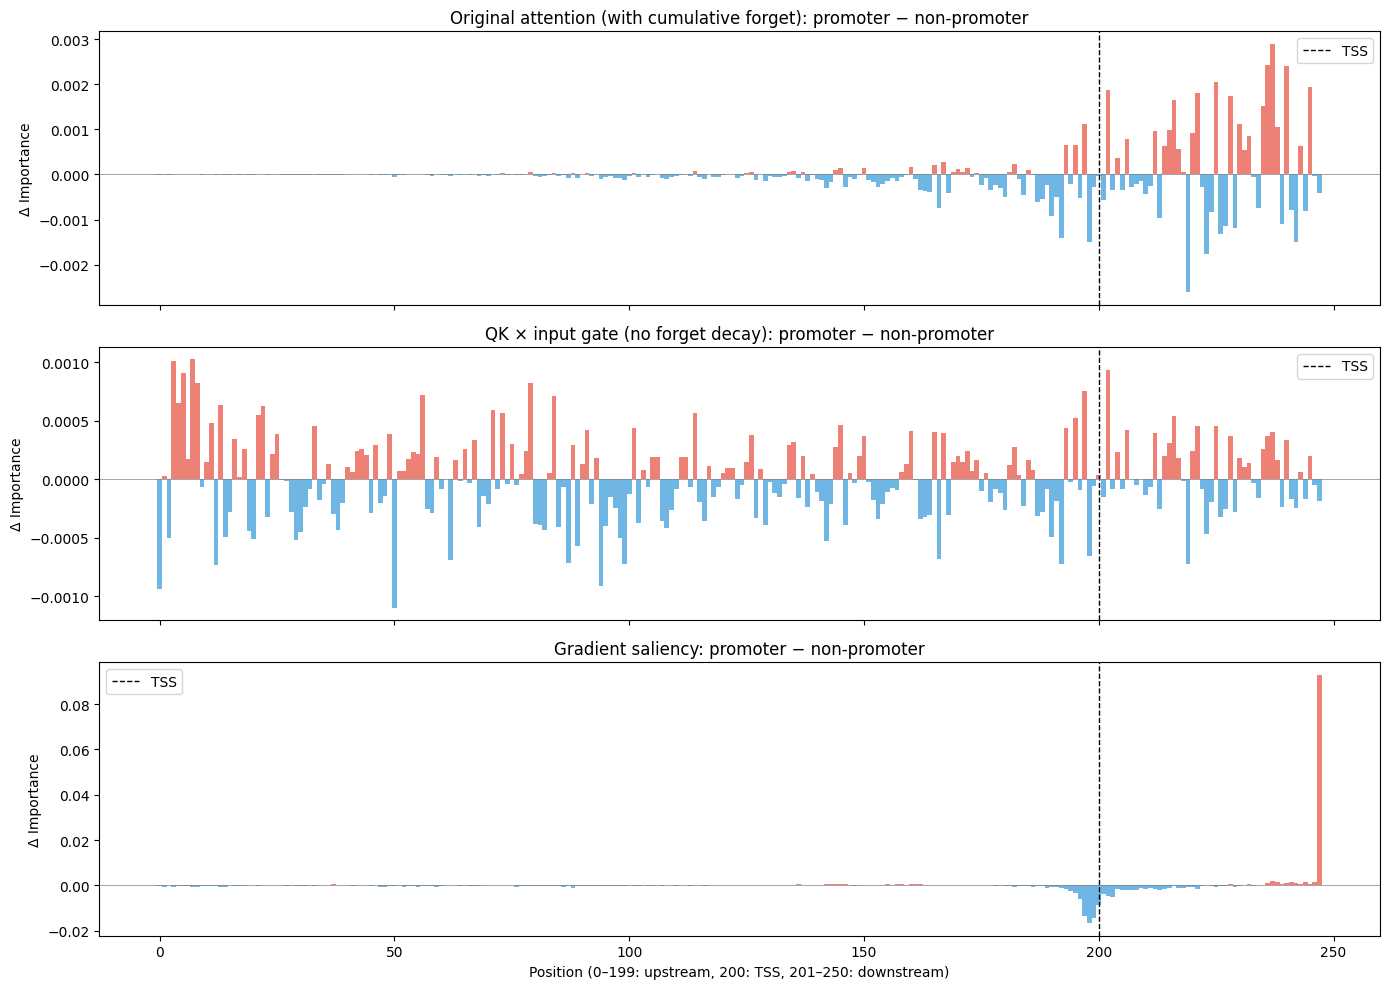

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

methods = [
    ("Original attention (with cumulative forget)", orig_prom, orig_nonprom),
    ("QK × input gate (no forget decay)", nf_prom, nf_nonprom),
    ("Gradient saliency", grad_prom, grad_nonprom),
]

for ax, (title, prom, nonprom) in zip(axes, methods):
    diff = (prom.mean(0) - nonprom.mean(0)).numpy()
    colors = ['#E74C3C' if d > 0 else '#3498DB' for d in diff]
    ax.bar(range(len(diff)), diff, width=1, color=colors, alpha=0.7)
    ax.set_title(f'{title}: promoter − non-promoter')
    ax.set_ylabel('Δ Importance')
    ax.axvline(x=200, color='black', linestyle='--', linewidth=1, label='TSS')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.legend()

axes[-1].set_xlabel('Position (0–199: upstream, 200: TSS, 201–250: downstream)')
plt.tight_layout()
plt.show()

### Gradient saliency и внимание без forget для двух классов отдельно

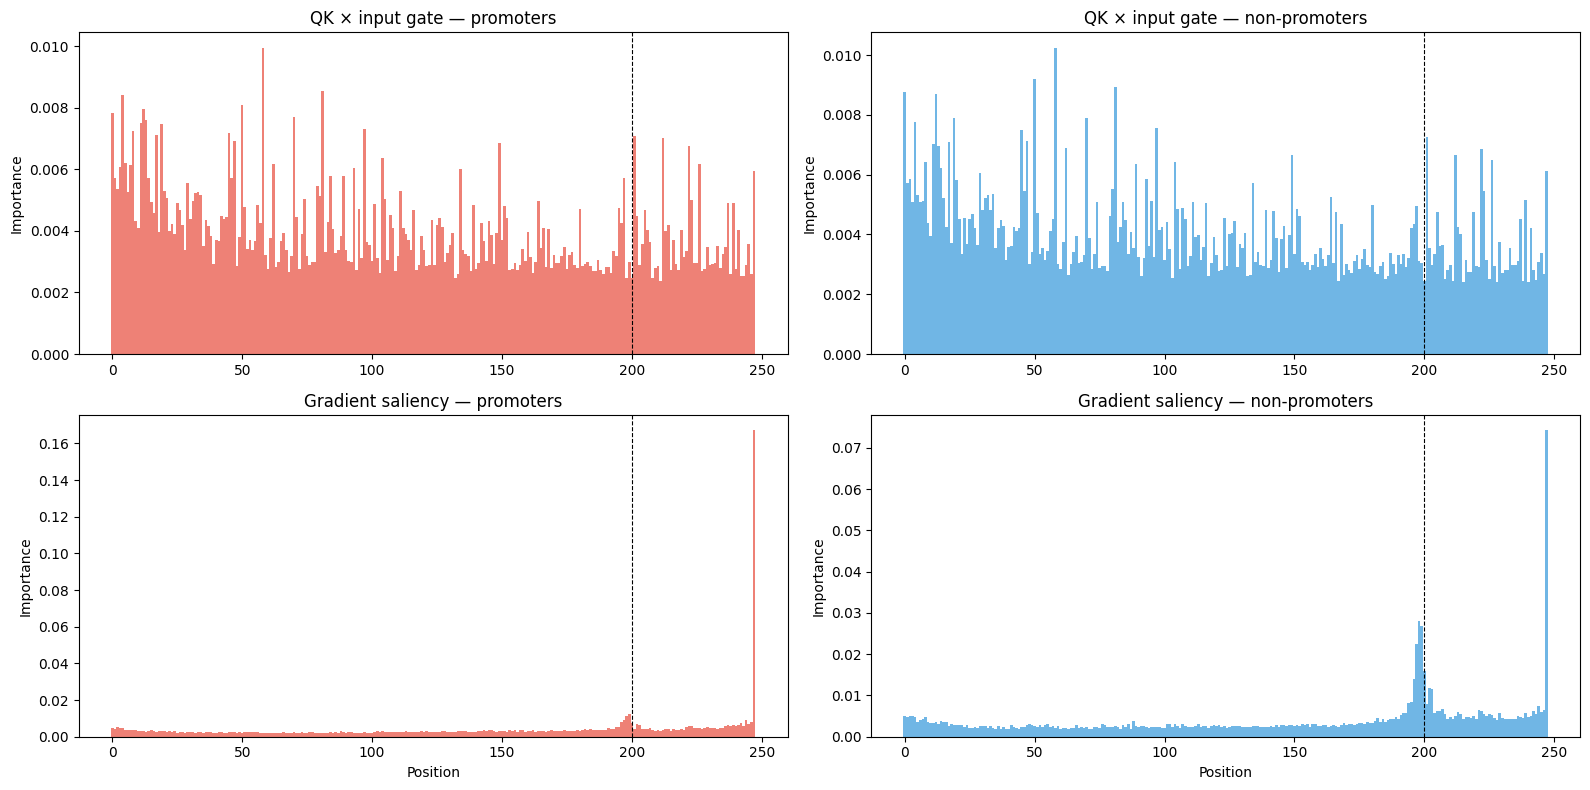

In [20]:
SEQ_LEN = 251 - k + 1
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

avg_nf_prom = nf_prom.mean(0).numpy()
avg_nf_nonprom = nf_nonprom.mean(0).numpy()
avg_grad_prom = grad_prom.mean(0).numpy()
avg_grad_nonprom = grad_nonprom.mean(0).numpy()

axes[0, 0].bar(range(SEQ_LEN), avg_nf_prom, width=1, color='#E74C3C', alpha=0.7)
axes[0, 0].set_title('QK × input gate — promoters')
axes[0, 0].axvline(x=200, color='black', linestyle='--', linewidth=0.8)

axes[0, 1].bar(range(SEQ_LEN), avg_nf_nonprom, width=1, color='#3498DB', alpha=0.7)
axes[0, 1].set_title('QK × input gate — non-promoters')
axes[0, 1].axvline(x=200, color='black', linestyle='--', linewidth=0.8)

axes[1, 0].bar(range(SEQ_LEN), avg_grad_prom, width=1, color='#E74C3C', alpha=0.7)
axes[1, 0].set_title('Gradient saliency — promoters')
axes[1, 0].axvline(x=200, color='black', linestyle='--', linewidth=0.8)

axes[1, 1].bar(range(SEQ_LEN), avg_grad_nonprom, width=1, color='#3498DB', alpha=0.7)
axes[1, 1].set_title('Gradient saliency — non-promoters')
axes[1, 1].axvline(x=200, color='black', linestyle='--', linewidth=0.8)

for ax in axes.flat:
    ax.set_ylabel('Importance')
axes[1, 0].set_xlabel('Position')
axes[1, 1].set_xlabel('Position')
plt.tight_layout()
plt.show()

### Эксперименты

| Конфигурация | Val F1 | Комментарий |
| --- | --- | --- |
| 1 слой mLSTM baseline | 0.81 | underfit |
| 3 слоя mLSTM | 0.81 | не помогло |
| 1 слой + k-mer токенайзер | 0.85 | помогло, undefit |
| 2 слоя + k-mer | 0.86 | увеличение помогло |
| 3 слоя + k-mer | 0.85 | тут уже переобучается |

k=4 Показал себя наилучшим образом. Обычно последовательности, которые встречаются в промотерах состоят из 6-8 нуклеотидов.
Видимо пересекающиеся токены несут больше информации, или модель распознает другие паттерны (claude подсказывет, что это CpG острова)

Но по графику gradient sliency, видно, что все-же ключевую роль в решении модели играют регионы рядос с TSS (там в основном и живут отличительные признаки промотеров)

Но внимание модели распределено более менее равномерно и одиаково для обоих классов, получается, что lstm просто записывает контекст,
а все предсказывает линейный слой.